In [1]:
import pandas as pd

In [2]:

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
display(df.head())
df.info()
display(df.describe())
df.shape

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


(1200, 13)

In [3]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

depression_label
0    1169
1      31
Name: count, dtype: int64

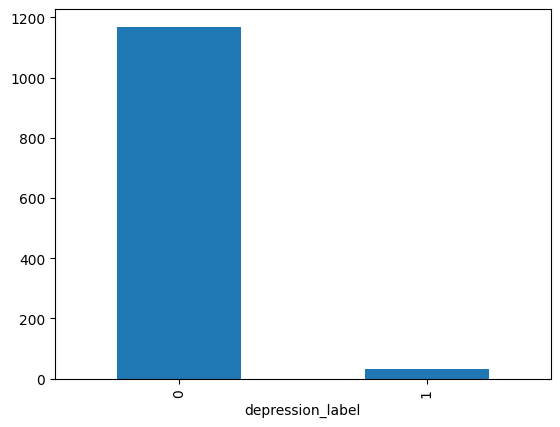

In [5]:
df['depression_label'].value_counts()
counts = df['depression_label'].value_counts()
counts.plot.bar()
counts

The dataset is severely imbalanced, with the positive class (depression_label=1) representing only 2.6% of samples. This limits the usefulness of accuracy as an evaluation metric, motivating our choice of F1 and ROC-AUC, and requires the use of stratified sampling and class-weighted models.

In [6]:
X = df.drop(columns=['depression_label'])   # 拿掉答案那欄,剩下都是線索
y = df['depression_label']                  # 只挑「答案」那欄
X.shape, y.shape                             # 確認形狀

((1200, 12), (1200,))

In [7]:
X = pd.get_dummies(X, drop_first=True, dtype=int)
X.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,1,1,0,1,0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,0,1,0,0
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,1,0,0,0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,1,0,1,0,1
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,0,0,0,1


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((960, 14), (240, 14))

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # 只用 train 學 mean/std,再套用
X_test  = scaler.transform(X_test)        # 用 train 的 mean/std 套到 test

X_train.shape, X_test.shape

((960, 14), (240, 14))

In [10]:
# ============================================
# find best threshold for F2-score
# ============================================

import numpy as np
from sklearn.metrics import fbeta_score, make_scorer, precision_score, recall_score, confusion_matrix

def find_best_threshold(proba, y_test, beta=2.0):

    thresholds = np.arange(0.001, 0.953, 0.001)

    best_t = None
    best_f2 = -1

    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        f2 = fbeta_score(y_test, y_pred, beta=beta)

        if f2 > best_f2:
            best_f2 = f2
            best_t = t

    y_pred_best = (proba >= best_t).astype(int)
    cm = confusion_matrix(y_test, y_pred_best)

    return {
        "best_threshold": best_t,
        "y_pred": y_pred_best,
        "best_f2": best_f2,
        "precision": precision_score(y_test, y_pred_best),
        "recall": recall_score(y_test, y_pred_best),
        "confusion_matrix": cm
    }

In [11]:
# ============================================
# custom scorer for GridSearchCV using F2-score with threshold tuning
# ============================================

def f2_with_threshold_scorer(estimator, X, y):
    # 1. get predicted probabilities from the estimator
    proba = estimator.predict_proba(X)[:, 1]

    # 2. use find_best_threshold() to find the best threshold
    result = find_best_threshold(proba, y, beta=2.0)

    # 3. return the F2-score to GridSearchCV
    return result["best_f2"]

In [12]:
# ============================================
# evaluation and visualization functions
# ============================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report, roc_curve, auc
)

def get_scores(classifier, X_test, y_test=y_test):
    X_test = X_test if X_test is not None else X_test
    proba = classifier.predict_proba(X_test)[:, 1]
    result = find_best_threshold(proba, y_test)
    y_pred = result['y_pred']
    f2 = result['best_f2']
    recall = result['recall']
    precision = result['precision']
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    roc_auc = roc_auc_score(y_test, proba)
    accuracy = accuracy_score(y_test, y_pred)
    print("F2:", f2, "\nRecall:", recall, "\nF1:", f1, "\nROC AUC:", roc_auc, "\nAccuracy:", accuracy, "\nPrecision:", precision)
    se = pd.Series([y_pred, proba, f2, recall, f1, accuracy, roc_auc, precision], index=['y_pred', 'proba', 'F2', 'Recall', 'F1', 'Accuracy', 'ROC AUC', 'Precision'])

    return se

def plot_confusion_matrix(y_pred, y_test=y_test):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
    plt.show()

# metrics = ['F2', 'Recall', 'F1', 'Accuracy', 'ROC AUC', 'Precision']
metrics = ['F2', 'Recall', 'ROC AUC', 'Precision']
def compare_multiple_scores(metrics, before_scores, after_scores_list, labels=None, title="Performance Comparison"):
    x = np.arange(len(metrics))
    width = 0.15  # each bar width
    
    plt.figure(figsize=(12,6))
    
    # baseline (Before)
    plt.bar(x - width, before_scores, width, label='Logistic Regression', color='skyblue')
    
    # models After
    for i, scores in enumerate(after_scores_list):
        offset = (i) * width
        plt.bar(x + offset, scores, width, label=labels[i] if labels else f'After {i+1}')
        # at each bar, show the value
        for j, v in enumerate(scores):
            plt.text(j + offset, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
    
    # baseline value labels
    for j, v in enumerate(before_scores):
        plt.text(j - width, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
    
    plt.xticks(x, metrics)
    plt.ylabel('Score')
    plt.ylim(0, 1.1)
    plt.title(title)
    plt.legend()
    plt.show()

def plot_roc_curve(y_score, y_test=y_test):
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0,1],[0,1],'k--', alpha=0.6)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('ROC Curve'); plt.legend(); plt.show()

In [13]:
# ============================================
# comprehensive evaluation function with diagnosis
# ============================================

def evaluate_fit(model, X_train, y_train, X_test, y_test, beta=2.0):
    # ---------- training set ----------
    proba_train = model.predict_proba(X_train)[:, 1]
    y_pred_train = (proba_train >= 0.5).astype(int)

    train_f2 = fbeta_score(y_train, y_pred_train, beta=beta)
    train_recall = recall_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_acc = accuracy_score(y_train, y_pred_train)
    train_auc = roc_auc_score(y_train, proba_train)

    # ---------- testing set ----------
    proba_test = model.predict_proba(X_test)[:, 1]
    y_pred_test = (proba_test >= 0.5).astype(int)

    test_f2 = fbeta_score(y_test, y_pred_test, beta=beta)
    test_recall = recall_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_acc = accuracy_score(y_test, y_pred_test)
    test_auc = roc_auc_score(y_test, proba_test)

    # ---------- print results ----------
    # print("=== Train Scores ===")
    # print(f"F2: {train_f2:.4f}, Recall: {train_recall:.4f}, Precision: {train_precision:.4f}, "
    #       f"Accuracy: {train_acc:.4f}, ROC-AUC: {train_auc:.4f}")

    # print("\n=== Test Scores ===")
    # print(f"F2: {test_f2:.4f}, Recall: {test_recall:.4f}, Precision: {test_precision:.4f}, "
    #       f"Accuracy: {test_acc:.4f}, ROC-AUC: {test_auc:.4f}")

    # ---------- model diagnosis ----------
    print("\n=== Model Diagnosis ===")

    # score gaps
    f2_gap = train_f2 - test_f2
    auc_gap = train_auc - test_auc

    # Overfitting
    if train_f2 > 0.8 and f2_gap > 0.15:
        print("⚠️ model Overfitting：training score is high but testing score is significantly lower")
    # Underfitting
    elif train_f2 < 0.6 and test_f2 < 0.6:
        print("⚠️ model Underfitting：training and testing scores are both low, model is not learning well")
    # normal
    else:
        print("✅ model performance is normal：training and testing scores are close, no obvious overfitting or underfitting")

    return {
        # "train_f2": train_f2,
        # "test_f2": test_f2,
        # "train_auc": train_auc,
        # "test_auc": test_auc,
        "diagnosis": "overfit" if train_f2 > 0.8 and f2_gap > 0.15 else
                     "underfit" if train_f2 < 0.6 and test_f2 < 0.6 else
                     "good"
    }

F2: 0.8823529411764706 
Recall: 1.0 
F1: 0.7499999999999999 
ROC AUC: 0.9943019943019943 
Accuracy: 0.9833333333333333 
Precision: 0.6


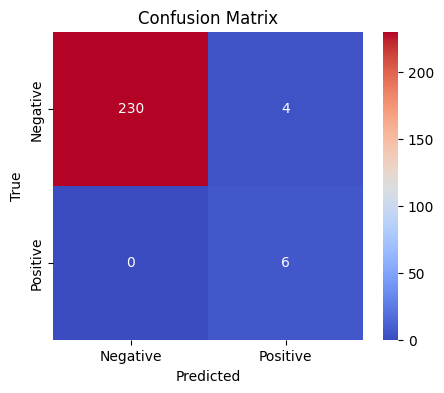


=== Model Diagnosis ===
✅ model performance is normal：training and testing scores are close, no obvious overfitting or underfitting


{'diagnosis': 'good'}

In [14]:
# ============================================
# Logistic Regression
# ============================================

from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# define Logistic Regression model with balanced class weights
log_reg = LogisticRegression(class_weight="balanced", random_state=42, max_iter=5000, verbose=0)
log_reg_trained = log_reg

pipe_log_reg = ImbPipeline([('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)), ('clf', log_reg_trained)])
pipe_log_reg.fit(X_train, y_train)
log_reg_scores = get_scores(pipe_log_reg, X_test)
plot_confusion_matrix(log_reg_scores['y_pred'])

evaluate_fit(pipe_log_reg, X_train, y_train, X_test, y_test)

Best params: {'C': 0.1, 'solver': 'liblinear'}
F2: 0.8823529411764706 
Recall: 1.0 
F1: 0.7499999999999999 
ROC AUC: 0.9957264957264956 
Accuracy: 0.9833333333333333 
Precision: 0.6


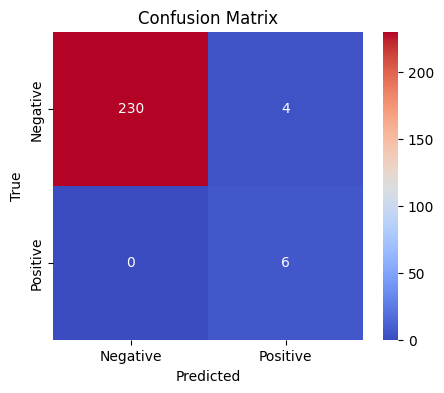


=== Model Diagnosis ===
✅ model performance is normal：training and testing scores are close, no obvious overfitting or underfitting


{'diagnosis': 'good'}

In [15]:
# ============================================
# Logistic Regression + GridSearchCV
# ============================================

import warnings
from sklearn.exceptions import ConvergenceWarning, FitFailedWarning

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=ConvergenceWarning)
    warnings.simplefilter("ignore", category=FitFailedWarning)

# 1. Define parameters for GridSearchCV
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

# 2. Define StratifiedKFold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. GridSearchCV
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring=f2_with_threshold_scorer,
    cv=cv,
    n_jobs=-1
)

# 4. Train model
grid_search.fit(X_train, y_train)
print("Best params:", grid_search.best_params_)

# 5. Best model
grid_log_reg = grid_search.best_estimator_

# 6. Predict and get scores
grid_scores = get_scores(grid_log_reg, X_test)

# 7. Evaluate
plot_confusion_matrix(grid_scores['y_pred'])
evaluate_fit(grid_log_reg, X_train, y_train, X_test, y_test)

In [16]:
# ============================================
# Using RFE for Feature Selection
# ============================================

from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline

In [17]:
logreg = LogisticRegression(max_iter=5000)

In [18]:
feature_names = X.columns

rfe = RFE(
    estimator=logreg,
    n_features_to_select=7
)

rfe.fit(X_train, y_train)

selected_features = feature_names[rfe.support_]

print(selected_features)

Index(['daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
       'academic_performance', 'stress_level', 'anxiety_level', 'gender_male'],
      dtype='str')


In [19]:
feature_ranking = pd.DataFrame({
    'Feature': feature_names,
    'Ranking': rfe.ranking_
})

print(feature_ranking.sort_values(by='Ranking'))

                            Feature  Ranking
1          daily_social_media_hours        1
2                       sleep_hours        1
3          screen_time_before_sleep        1
4              academic_performance        1
6                      stress_level        1
7                     anxiety_level        1
9                       gender_male        1
10         platform_usage_Instagram        2
8                   addiction_level        3
5                 physical_activity        4
0                               age        5
12     social_interaction_level_low        6
13  social_interaction_level_medium        7
11            platform_usage_TikTok        8


F2: 0.8333333333333334 
Recall: 1.0 
F1: 0.6666666666666666 
ROC AUC: 0.995014245014245 
Accuracy: 0.975 
Precision: 0.5


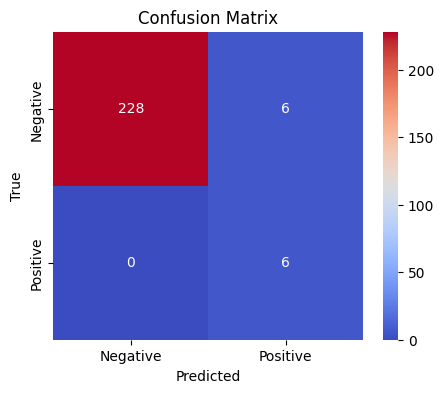


=== Model Diagnosis ===
⚠️ model Underfitting：training and testing scores are both low, model is not learning well


{'diagnosis': 'underfit'}

In [20]:
X_train_selected = rfe.transform(X_train)
X_test_selected = rfe.transform(X_test)
model_selected = ImbPipeline([
    ("scaler", StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ("logreg", LogisticRegression(max_iter=5000))
])

param_grid_pipe = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid_pipe = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_pipe,
    scoring=f2_with_threshold_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=0 )

grid_pipe.fit(X_train_selected, y_train)

find_features_model = grid_pipe.best_estimator_

find_features_scores = get_scores(find_features_model,X_test_selected)
plot_confusion_matrix(find_features_scores['y_pred'])
evaluate_fit(find_features_model, X_train_selected, y_train, X_test_selected, y_test)


F2: 0.8064516129032258 
Recall: 0.8333333333333334 
F1: 0.7692307692307692 
ROC AUC: 0.9893162393162394 
Accuracy: 0.9875 
Precision: 0.7142857142857143


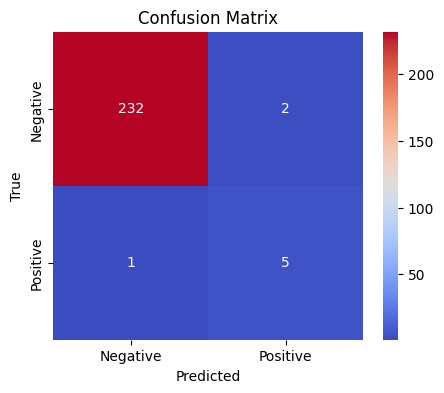


=== Model Diagnosis ===
✅ model performance is normal：training and testing scores are close, no obvious overfitting or underfitting


{'diagnosis': 'good'}

In [21]:
# ============================================
# Selected Features with RFE
# ============================================

feature_names = X.columns
selected_features = ['sleep_hours', 'stress_level', 'anxiety_level', 'daily_social_media_hours', 'screen_time_before_sleep', 'gender', 'addiction_level']
mask = [f in selected_features for f in feature_names]
X_train_selected = X_train[:, mask]

selected_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(class_weight="balanced", random_state=42, verbose=0))
])

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__solver": ["liblinear", "lbfgs"]
}

selected_grid = GridSearchCV(
    estimator=selected_pipe,
    param_grid=param_grid,
    scoring=f2_with_threshold_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=0
)

selected_grid.fit(X_train_selected, y_train)
selected_features_model = selected_grid.best_estimator_
selected_features_scores = get_scores(selected_features_model, X_test[:, mask])
plot_confusion_matrix(selected_features_scores['y_pred'])

evaluate_fit(selected_features_model, X_train_selected, y_train, X_test[:, mask], y_test)

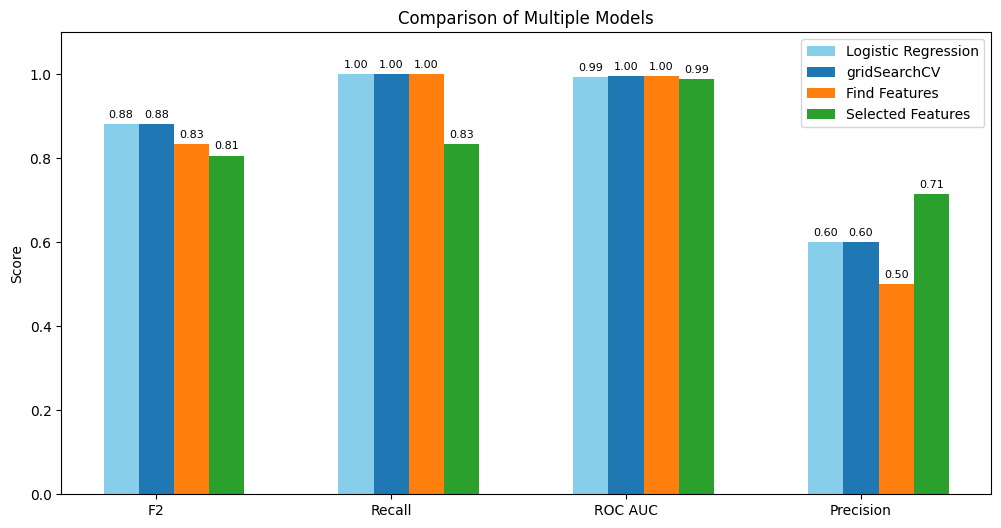

In [22]:
# ============================================
# compare all models
# ============================================

org_model = [log_reg_scores['F2'], log_reg_scores['Recall'], log_reg_scores['ROC AUC'], log_reg_scores['Precision']]
after_models = [
    [grid_scores['F2'], grid_scores['Recall'], grid_scores['ROC AUC'], grid_scores['Precision']],
    [find_features_scores['F2'], find_features_scores['Recall'], find_features_scores['ROC AUC'], find_features_scores['Precision']],
    [selected_features_scores['F2'], selected_features_scores['Recall'], selected_features_scores['ROC AUC'], selected_features_scores['Precision']]
    ]
labels = ['gridSearchCV', 'Find Features', 'Selected Features']
compare_multiple_scores(metrics, org_model, after_models, labels, title="Comparison of Multiple Models")


Recursive Feature Elimination (RFE) was used to automatically identify the most important features for Logistic Regression. The model recursively removed less important features and retained the top-performing subset of features. Performance was then re-evaluated using the selected feature set.

After applying RFE feature selection, the F2 score slightly decreased. This suggests that some removed features still contained useful predictive information. Logistic Regression already includes regularization, therefore aggressive feature elimination may reduce the model’s ability to capture important patterns in the dataset.

Then, I try to use another method to get a better F2 score by dropping the best combination of features

    Number of Features  F2 Score
0                   10  0.882353
1                    9  0.810811
2                    6  0.769231
3                    8  0.769231
4                    5  0.750000
5                    7  0.750000
6                   11  0.735294
7                   12  0.735294
8                   13  0.735294
9                   14  0.735294
10                   4  0.681818
11                   3  0.555556
12                   2  0.454545
13                   1  0.263158

Best Number of Features:
10

Best F2 Score:
0.8823529411764706

Best Selected Features:
Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'academic_performance', 'stress_level', 'anxiety_level',
       'addiction_level', 'gender_male', 'platform_usage_Instagram',
       'social_interaction_level_medium'],
      dtype='str')

Removed Features:
Index(['screen_time_before_sleep', 'physical_activity',
       'platform_usage_TikTok', 'social_interaction_level_low'],
      dtype='str')


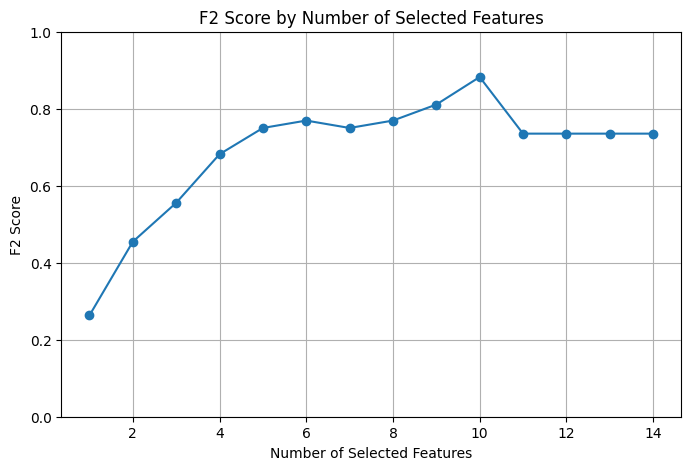

In [23]:
# ============================================
# RFE with Different Number of Features
# ============================================

results = []

best_f2 = 0
best_rfe = None
best_n = 0

for n in range(1, X_train.shape[1] + 1):
    
    rfe = RFE(
        estimator=LogisticRegression(
            max_iter=5000,
            class_weight="balanced"
        ),
        n_features_to_select=n
    )
    
    rfe.fit(X_train, y_train)
    
    X_train_rfe = rfe.transform(X_train)
    X_test_rfe = rfe.transform(X_test)
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            max_iter=5000,
            class_weight="balanced"
        ))
    ])
    
    model.fit(X_train_rfe, y_train)
    
    y_pred_rfe = model.predict(X_test_rfe)
    
    current_f2 = fbeta_score(y_test, y_pred_rfe, beta=2.0)
    
    results.append({
        "Number of Features": n,
        "F2 Score": current_f2
    })
    

    if current_f2 > best_f2:
        best_f2 = current_f2
        best_rfe = rfe
        best_n = n

rfe_results = pd.DataFrame(results)

print(
    rfe_results
    .sort_values(by="F2 Score", ascending=False)
    .reset_index(drop=True)
)

print("\nBest Number of Features:")
print(best_n)

print("\nBest F2 Score:")
print(best_f2)

best_features = feature_names[best_rfe.support_]

print("\nBest Selected Features:")
print(best_features)

removed_features = feature_names[~best_rfe.support_]

print("\nRemoved Features:")
print(removed_features)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))


plt.plot(
    rfe_results["Number of Features"],
    rfe_results["F2 Score"],
    marker="o"
)

plt.xlabel("Number of Selected Features")
plt.ylabel("F2 Score")
plt.title("F2 Score by Number of Selected Features")
plt.ylim(0, 1)
plt.grid(True)

plt.show()

The best F2 score was achieved when retaining 10 features. Removing too many features reduced model performance, suggesting that additional features still contributed useful predictive information.

In [24]:
# # ============================================
# # 1. Use best RFE-selected features
# X_train_best_rfe = best_rfe.transform(X_train)
# X_test_best_rfe = best_rfe.transform(X_test)

# # 2. Train Logistic Regression using selected features
# model_best_rfe = Pipeline([
#     ("scaler", StandardScaler()),
#     ("logreg", LogisticRegression(
#         max_iter=5000,
#         class_weight="balanced",
#         random_state=42
#     ))
# ])

# model_best_rfe.fit(X_train_best_rfe, y_train)

# # 3. Get predicted probabilities
# y_prob_best_rfe = model_best_rfe.predict_proba(X_test_best_rfe)[:, 1]

# # 4. Threshold tuning
# precision, recall, thresholds = precision_recall_curve(y_test, y_prob_best_rfe)

# f1_scores = 2 * precision * recall / (precision + recall + 1e-10)

# best_index = np.argmax(f1_scores[:-1])
# best_threshold_rfe = thresholds[best_index]

# print("Best threshold after RFE:", best_threshold_rfe)
# print("Best F1 after RFE + threshold tuning:", f1_scores[best_index])

# # 5. Predict using best threshold
# y_pred_best_rfe_threshold = (y_prob_best_rfe >= best_threshold_rfe).astype(int)

# # 6. Evaluate
# print("F1 after Best RFE + Threshold Tuning:")
# print(f1_score(y_test, y_pred_best_rfe_threshold, zero_division=0))

# print("\nClassification Report:")
# print(classification_report(y_test, y_pred_best_rfe_threshold, zero_division=0))

# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred_best_rfe_threshold))

The RFE-based feature selection process did not further increase the final F1 score compared to the full-feature model. However, the model maintained the same performance while using fewer features, suggesting that several original features were redundant or less informative. This indicates that feature reduction helped simplify the model without sacrificing predictive capability.